<a href="https://colab.research.google.com/github/gloriaalzate/FreeCodeCamp-Pandas-Real-Life-Example/blob/master/Act1_caracteristicasOdio_Gloria_Lida_Alzate_V5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Universidad Internacional de La Rioja (UNIR) - Máster Universitario en Inteligencia Artificial - Procesamiento del Lenguaje Natural**

***
Datos del alumno (GLORIA LIDA ALZATE SUAREZ):

---



Fecha: 5/12/2025
***

<span style="font-size: 30pt; font-weight: bold; color:#FF8C00;">Trabajo: Caracterización de textos</span>

**Objetivos**

Con esta actividad se tratará de que el alumno se familiarice con el manejo de la librería spacy, así como con los conceptos básicos de manejo de las técnicas NER

**Descripción**

En esta actividad debes procesar de forma automática un texto en lenguaje natural para detectar características básicas en el mismo, y para identificar y etiquetar las ocurrencias de conceptos como localización, moneda, empresas, etc.

En la primera parte del ejercicio se proporciona un código fuente a través del cual se lee un archivo de texto y se realiza un preprocesado del mismo. En esta parte el alumno tan sólo debe ejecutar y entender el código proporcionado.

En la segunda parte del ejercicio se plantean una serie de preguntas que deben ser respondidas por el alumno. Cada pregunta deberá responderse con un fragmento de código fuente que esté acompañado de la explicación correspondiente. Para elaborar el código solicitado, el alumno deberá visitar la documentación de la librería spacy, cuyos enlaces se proporcionarán donde corresponda.

# Parte 1: carga y preprocesamiento del texto a analizar

Observa las diferentes librerías que se están importando.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Instalar y cargar spaCy
!pip install -q spacy

# Descargar modelo de español
!python -m spacy download es_core_news_md

# Importar librerías (SIN import es_core_news_md)
import pathlib
import spacy
import pandas as pd
from spacy import displacy
import csv

# Cargar el modelo CORRECTAMENTE
nlp = spacy.load("es_core_news_md")

print("Modelo cargado correctamente")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 16.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Modelo cargado correctamente


El siguiente código simplemente carga y preprocesa el texto. Para ello, lo primero que hace es cargar un modelo de lenguaje previamente entrenado. En este caso, se utiliza <i>es_core_news_md</i>:

https://spacy.io/models/es#es_core_news_md


In [3]:
import spacy
nlp = spacy.load("es_core_news_md")
print("Modelo cargado correctamente")

Modelo cargado correctamente


El objeto <i>nlp</i> permite utilizar el modelo de lenguaje cargado, de forma que se puede procesar un texto y obtenerlo en su versión preprocesada. Así, nos permite realizar las diferentes tareas. En este caso, vamos a utilizar el pipeline para hacer un preprocesamiento básico, que consiste en tokenizar el texto.

In [4]:
from pathlib import Path

import pandas as pd



# Rutas de entrada/salida (ajustad el nombre si hace falta)

input_path = Path("/content/drive/MyDrive/Act1_PLN/ds2.csv")  # fichero original
tmp_path = Path("/content/drive/MyDrive/Act1_PLN/comentarios_sin_bytes_raros.csv")
output_path = Path("/content/drive/MyDrive/Act1_PLN/comentarios_limpio_utf8.csv")



# Algunos bytes problemáticos detectados en el archivo original
BAD_BYTES = {0xBF, 0xA1, 0xB3}  # ¿, ¡, ³ en cp1252



# 1) Eliminamos esos bytes a nivel binario

with input_path.open("rb") as f_in, tmp_path.open("wb") as f_out:
    for raw_line in f_in:
        cleaned = bytes(b for b in raw_line if b not in BAD_BYTES)
        f_out.write(cleaned)



# 2) Leemos el CSV resultante asumiendo codificación latin1 / cp1252
df = pd.read_csv(tmp_path, sep=";", encoding="latin1", dtype=str)



# 3) Arreglamos el "mojibake" típico (debÃa -> debía, etc.)
def arreglar_mojibake(s):
    if not isinstance(s, str):
        return s
    try:
        reparado = s.encode("latin1").decode("utf-8")
        return reparado
    except UnicodeError:
        return s



text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = df[col].apply(arreglar_mojibake)



# 4) Guardamos ya todo en UTF-8 limpio

df.to_csv(output_path, sep=";", index=False, encoding="utf-8")





print("Archivo limpio guardado como:", output_path)


data = pd.read_csv(output_path, sep=";", encoding="utf-8")

Archivo limpio guardado como: /content/drive/MyDrive/Act1_PLN/comentarios_limpio_utf8.csv


/tmp/ipython-input-2734020132.py:64: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(output_path, sep=";", encoding="utf-8")


El código anterior carga el archivo CSV (opcionalmente con un límite de líneas a leer) y genera la variable <i>data</i>, que contiene un Dataframe (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) con los datos leídos del CSV.

Te vendrá bien conocer la siguiente documentación:
<ul>
    <li>https://spacy.io/api/doc</li>
    <li>https://spacy.io/api/token</li>
    <li>https://spacy.io/api/morphology#morphanalysis</li>
</ul>

### Playground

Utiliza este espacio para hacer pruebas y ensayos con las variables generadas con el código previo. A modo de ejemplo, se ofrece código que realiza las siguientes tareas:


- leer un número dado de líneas del Dataframe y generar dos listas con los valores (se pueden leer directamente del DataFrame, se muestra el ejemplo como una opción más)
- procesar el texto de cada comentario


Para procesarlo, hay utilizar el objeto <i>nlp</i> y así obtener objetos de la clase <i>Doc</i> (https://spacy.io/api/doc)

Visita la documentación de dicha clase y experimenta probando las diferentes funciones y atributos

In [5]:
#código de prueba
#Numero de líneas
lines_number = 10000
#print(data["CONTENIDO A ANALIZAR"][1])
#print(data["INTENSIDAD"][1])
doc = []
value = []

#con el bucle, generamos seldas listas con los comentarios ya parseados y con el valor de la intensidad.
for i in range(0, lines_number):

    #en un primer paso se parsea el comentario. En el segundo paso se añade el objeto a la lista.
    tmp_doc = nlp(data["CONTENIDO A ANALIZAR"][i])
    doc.append(tmp_doc)

    #en un primer paso extrae el valor. En el segundo paso se añade el valor a la lista.
    tmp_value = data["INTENSIDAD"][i]
    value.append(tmp_value)


#ejemplo de cómo recorrer un comentario palabra por palabra.
for token in doc[1]:
    print(token)

el
real
madrid
ha
puesto
punto
y
final
a
su
andadura
en
la
copa
del
rey
en
el
primer
escalón
.
los
de
zidane
han
caí­do
ante
el
alcoyano
,
de
segunda
b
,
a
pesar
de
empezar
ganando
y
jugar
con
un
hombre
menos
en
la
prórroga
.
el
técnico
francés
dispuso
un
equipo
plagado
de
los
menos
habituales
,
con
vinicius
y
mariano
en
ataque
.
ninguno
de
los
dos
logró
crear
ocasiones
.
fue
militao
el
que
marcó
el
gol
del
madrid
,
justo
antes
del
descanso
.
en
la
segunda
parte
intentaron
cerrar
el
partido
,
pero
sin
el
colmillo
suficiente
y
el
modesto
alcoyano
aprovechó
un
córner
para
empatar
el
partido
a
cinco
minutos
para
el
final
.
el
empate
sentó
como
un
jarro
de
agua
frí­a
a
los
blancos
,
que
lo
intentaron
en
el
tiempo
extra
a
falta
de
cinco
minutos
,
el
casanova
consiguió
el
gol
más
importante
de
su
vida
,
que
vale
la
clasificación
para
octavos
de
la
copa
.
el
madrid
de
zidane
queda
apeado
del
torneo
una
vez
más
,
por
lo
que
el
francés
se
quedará
sin
pelear
por
el
único
tí­tulo
que
no
ha
conseg

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 1.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuántos registros contiene el corpus?</span>

In [6]:
# Incluye aquí el código generado para poder responder a tu pregunta
len(data)
#len(data_comentarios)

575029

El corpus contiene 575,029 registros totales donde se puede concluir que el archivo ds2.csv despúes de cargarlo en la libreria de pandas, cada fila representa un mensaje en el corpus.

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 2.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuántas palabras totales hay en los comentarios del corpus?</span>

In [7]:
# Cargar el modelo de spaCy en español
nlp = spacy.load("es_core_news_md")

# Cantidad de palabras por comentario
num_palabras_por_comentario = []

for d in doc:
    palabras = sum(1 for token in d if token.is_alpha)  # cuenta solo palabras reales
    num_palabras_por_comentario.append(palabras)

# Total de palabras del corpus
total_palabras = sum(num_palabras_por_comentario)

print("Total de palabras en el corpus de 10.000 registros =", total_palabras)

Total de palabras en el corpus de 10.000 registros = 201430


Los resultados muestran 201.430 palabras, tuve que aplicar un pre-procesamiento con la librería SpaCy, que es la ideal para PLN. Primero cargamos el modelo robusto es_core_news_md de spaCy. ya que Spacy asigna atributos a cada pedacito de texto o cada token, se hace un filtro con if token.is_alpha ya que solo deja pasar los tokens que son alfabeticos y finalmente se hace el conteo final con la sumatoria.
Total de palabras en el corpus de 10.000 registros = 201.430


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 3.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuál es el número promedio de palabras en cada comentario?</span>

In [8]:
promedio_palabras  = sum(num_palabras_por_comentario)/len(num_palabras_por_comentario)
print("Promedio de palabras por comentario en el corpus de 10.000 registros =", promedio_palabras)

Promedio de palabras por comentario en el corpus de 10.000 registros = 20.143


El promedio de palabras es de 20.143 el sun(num_palabras_por_comentario) suma la cantidad de todas las palabras que se encontraron en los 10.000 comentarios del corpus. len(num_palabras_por_comentario) contaba cuántos elementos había en lista, lo que equivale al número total de comentarios que se analizaron. Luego se realiza la division del total de palabras y el total de comentarios para sacar el promedio.


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 4.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Considerando dos grupos de comentarios (odio y no odio) ¿Cuál es el número promedio de palabras en los comentarios de cada grupo?</span>

In [9]:
# Listas para almacenar la cantidad de palabras por grupo}
contenido_odio = []
contenido_no_odio = []
palabras_odio = []
palabras_no_odio = []


# Recorremos los documentos ya procesados
for i, d in enumerate(doc):
    # Cantidad de palabras reales del comentario i
    num_palabras = sum(1 for token in d if token.is_alpha)

    # Clasificación según INTENSIDAD
    if value[i] >0:
        palabras_odio.append(num_palabras)
        contenido_odio.append(d)
    else:
        palabras_no_odio.append(num_palabras)
        contenido_no_odio.append(d)

# Cálculo de promedios
promedio_odio = sum(palabras_odio) / len(palabras_odio)
promedio_no_odio = sum(palabras_no_odio) / len(palabras_no_odio)

print("Promedio de palabras en comentarios de ODIO =", promedio_odio)
print("Promedio de palabras en comentarios de NO ODIO =", promedio_no_odio)

Promedio de palabras en comentarios de ODIO = 21.2072192513369
Promedio de palabras en comentarios de NO ODIO = 20.05696065715521


Este código se encarga de calcular el promedio de la longitud de los comentarios de una forma segmentada, basandose en la etiqueta de clasificación (ODIO, NO ODIO). Donde cada categoría, sumó el total de palabras o los tokens alfabéticos y los dividió por la cantidad de comentarios que pertenecían a esa etiqueta. El análisis promedio dice que: Comentarios con Odio: Tienen un promedio de 21.2 palabras.
Comentarios de No Odio: Tienen un promedio de 20.05 palabras. En el siguiente código con la ayuda de Gemini Pro realicé el histograma para una mejor representación.

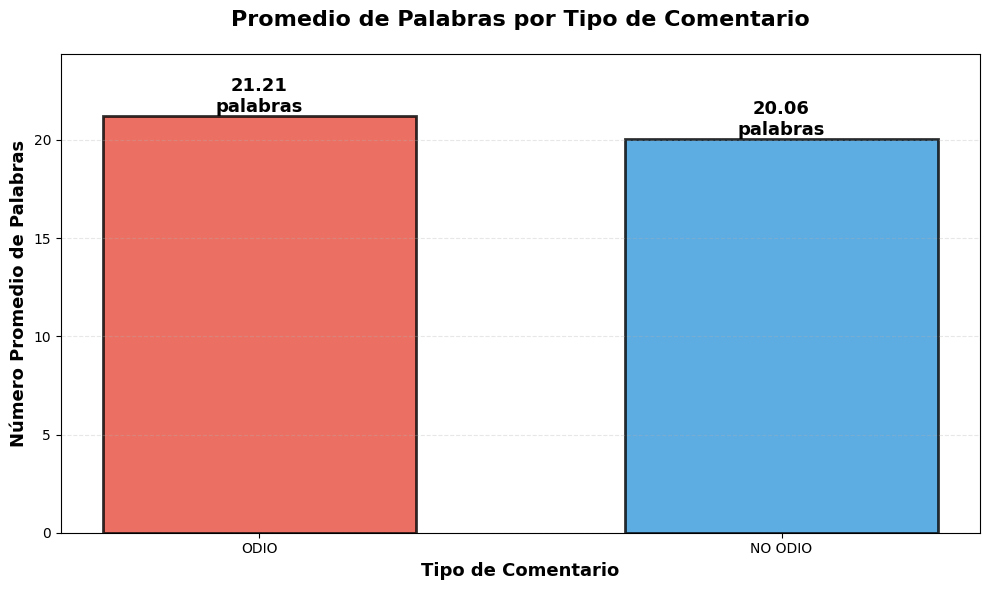


 Diferencia: 1.15 palabras
 Los comentarios de ODIO tienen en promedio 1.15 palabras MÁS


In [10]:
import matplotlib.pyplot as plt

# Datos
categorias = ['ODIO', 'NO ODIO']
promedios = [promedio_odio, promedio_no_odio]

# Crear gráfico
plt.figure(figsize=(10, 6))
colores = ['#E74C3C', '#3498DB']
barras = plt.bar(categorias, promedios, color=colores, alpha=0.8,
                  edgecolor='black', linewidth=2, width=0.6)

# Agregar valores sobre las barras
for barra, valor in zip(barras, promedios):
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura,
             f'{valor:.2f}\npalabras',
             ha='center', va='bottom', fontsize=13, fontweight='bold')

# Personalizar
plt.title('Promedio de Palabras por Tipo de Comentario',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Número Promedio de Palabras', fontsize=13, fontweight='bold')
plt.xlabel('Tipo de Comentario', fontsize=13, fontweight='bold')
plt.ylim(0, max(promedios) * 1.15)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Mostrar diferencia
diferencia = abs(promedio_odio - promedio_no_odio)
print(f"\n Diferencia: {diferencia:.2f} palabras")
if promedio_odio > promedio_no_odio:
    print(f" Los comentarios de ODIO tienen en promedio {diferencia:.2f} palabras MÁS")
else:
    print(f"Los comentarios de NO ODIO tienen en promedio {diferencia:.2f} palabras MÁS")

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 5.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Considerando dos grupos de comentarios (odio y no odio) ¿Cuál es el número promedio de oraciones en los comentarios de cada grupo?</span>

In [11]:
# Listas para almacenar la cantidad de oraciones por grupo
oraciones_odio = []
oraciones_no_odio = []

# Recorremos los documentos procesados
for i, d in enumerate(doc):
    # Contar oraciones reales
    num_oraciones = len(list(d.sents))

    # Clasificar según el valor de intensidad
    if value[i] >0:
        oraciones_odio.append(num_oraciones)
    else:
        oraciones_no_odio.append(num_oraciones)

# Calcular los promedios
promedio_oraciones_odio = sum(oraciones_odio) / len(oraciones_odio)
promedio_oraciones_no_odio = sum(oraciones_no_odio) / len(oraciones_no_odio)

print("Promedio de oraciones en comentarios de ODIO =", promedio_oraciones_odio)
print("Promedio de oraciones en comentarios de NO ODIO =", promedio_oraciones_no_odio)


Promedio de oraciones en comentarios de ODIO = 1.768716577540107
Promedio de oraciones en comentarios de NO ODIO = 1.7808041504539558


Se ha realizado con este código el calculo de el número promedio de oraciones pro comentario, segmentado por las categoría ODIO y NO ODIO. Se utiliza la libreria de Spacy para segmentar las oraciones. Comparando las respuestas puedo ver que ambos grupos tienen prácticamente la misma longitud de oración promedio. Esto implica que la diferencia en la clasificaci+on (ODIO vs NO ODIO) no se basa en la parte sintactica sino en el contendio ´léxico en la longitud total del mensaje.

Promedio de oraciones en comentarios de ODIO = 1.768716577540107

Promedio de oraciones en comentarios de NO ODIO = 1.7808041504539558

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 6.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Considerando dos grupos de comentarios (odio y no odio) ¿Cuál es el porcentaje de comentarios que contienen entidades NER en cada grupo?</span>

In [12]:
# Contadores
total_odio = 0
total_no_odio = 0
ner_odio = 0
ner_no_odio = 0

# Recorremos cada comentario procesado
for i, d in enumerate(doc):

    tiene_ner = len(d.ents) > 0  # Asgina un valor de falso o verdadero a la variable tiene_ner

    if value[i] >0:
        total_odio += 1
        if tiene_ner:
            ner_odio += 1
    else:
        total_no_odio += 1
        if tiene_ner:
            ner_no_odio += 1

# Cálculo de porcentajes
porcentaje_odio = (ner_odio / total_odio) * 100
porcentaje_no_odio = (ner_no_odio / total_no_odio) * 100

print("Porcentaje de comentarios con NER (ODIO):", porcentaje_odio, "%")
print("Porcentaje de comentarios con NER (NO ODIO):", porcentaje_no_odio, "%")

Porcentaje de comentarios con NER (ODIO): 37.967914438502675 %
Porcentaje de comentarios con NER (NO ODIO): 34.05750108084739 %


Se realiza una comparación de la densidad de entidades de nombre reconocido (NER), como los nombres propios y lugares, entre comentarios clasificados como ODIO y NO ODIO. Esto se logró segmentando el conteo de los comentarios que contienen las entidades por su etiqueta de intensidad. El resultado revela que el 37.96% de los mensajes de odio contienen NER, frente al 34.05% de los mensajes no odio, indicando que el discurso de odio es mas propesno a referenciar las entidades para una agresión.

Porcentaje de comentarios con NER (ODIO): 37.967914438502675 %

Porcentaje de comentarios con NER (NO ODIO): 34.05750108084739 %

Se presenta una gráfica para visualizar mejor las respuestas obtenidas.

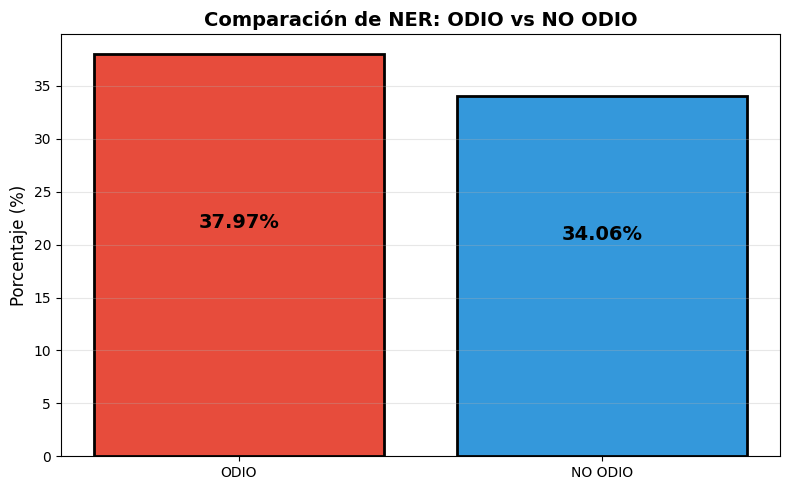

In [13]:
import matplotlib.pyplot as plt

# Crear gráfico simple
plt.figure(figsize=(8, 5))
plt.bar(['ODIO', 'NO ODIO'],
        [porcentaje_odio, porcentaje_no_odio],
        color=['#E74C3C', '#3498DB'],
        edgecolor='black',
        linewidth=2)

# Agregar los valores de porcentaje sobre cada barra
for barra, valor in zip(barras, [porcentaje_odio, porcentaje_no_odio]):
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura,
             f'{valor:.2f}%',
             ha='center', va='bottom',
             fontsize=14, fontweight='bold')

plt.title('Comparación de NER: ODIO vs NO ODIO', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



<span style="font-size: 16pt; font-weight: bold; color: #0098cd;">Plantea tus propias preguntas</span>

<span><b>Plantea al menos 4 características</b> del texto cuyo análisis permita una caracterización completa del texto. Puedes utilizar recomendaciones proporcionadas por la IA Generativa, si así lo deseas. Para cada una de las características planteadas, obtén valores separados para los grupos ODIO/NO-ODIO.</span>

<span>En la explicación aportada, deberás <b>explicar el significado de la característica planteada</b> así como la importancia de ésta en la caracterización del texto.</span>

<span style="font-size: 45pt; font-weight: bold; color: #0098cd;">Característica adicional 1.</span>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">[COMPLEJIDAD SINTACTICA]</span>

Explicación: Esta característica permite medir la densidad de relaciones grmaticasles (dependencias sintácticas) en un comentario mediante spaCy.

Importancia: captura los patrones estructurales del elnguaje como los comentarios de ODIO y NO ODIO. Sugiriendo que el discurso ofensibo puede ususar unas estructuras sintácticas más simples y directas. Aunque la diferencia sea pequeña, complementa las caractrísticas al analizar la dimensión gramatical, aportando información que modelos basados únicamente en palabras no pueden detectar.

In [14]:
sintaxis_odio = []
sintaxis_noodio = []

for i, d in enumerate(doc):

    deps_unicos = len(set([t.dep_ for t in d if t.is_alpha]))

    if value[i] >0:
        sintaxis_odio.append(deps_unicos)
    else:
        sintaxis_noodio.append(deps_unicos)

promedio_sint_odio = sum(sintaxis_odio) / len(sintaxis_odio)
promedio_sint_noodio = sum(sintaxis_noodio) / len(sintaxis_noodio)

print("Promedio de complejidad sintáctica (ODIO):", promedio_sint_odio)
print("Promedio de complejidad sintáctica (NO ODIO):", promedio_sint_noodio)

Promedio de complejidad sintáctica (ODIO): 8.953208556149733
Promedio de complejidad sintáctica (NO ODIO): 9.029182879377432


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Característica adicional 3.</span>

DENSIDAD DE PALABRAS EN MAYÚSCULA
Explicación: mide el promedio de palabras escritas completamente en mayúscula por comentario.

Importancia: en la comunicación por medios digitales, escribir en mayúsculas se interpreta como "gritar" o expresar eomociones intensas como (enojo, indignación, malestar, desacuerdo). Los comentarios de odio frecuentemente usan mayúsculas para enfatizar los insultos y esto nos permite identificar que es una característica que captura la intensidad emocional de un mensaje.

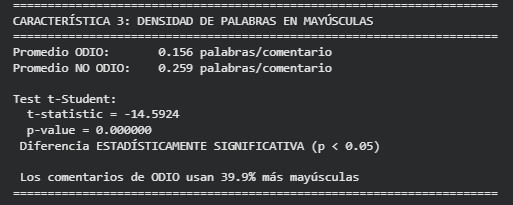

In [15]:
import re
import numpy as np
from scipy import stats

# Análisis de mayúsculas
def contar_mayusculas(texto):
    palabras = re.findall(r"\b\w+\b", str(texto))
    return sum(1 for p in palabras if p.isupper() and len(p) > 1)

data["mayusculas"] = data["CONTENIDO A ANALIZAR"].apply(contar_mayusculas)

# Separar por categoría
mayus_odio = data.loc[data["INTENSIDAD"] > 0, "mayusculas"]
mayus_no_odio = data.loc[data["INTENSIDAD"] == 0, "mayusculas"]

# Estadísticas
promedio_mayus_odio = mayus_odio.mean()
promedio_mayus_no_odio = mayus_no_odio.mean()

# Test estadístico
t_stat, p_value = stats.ttest_ind(mayus_odio.dropna(), mayus_no_odio.dropna())

print("\n" + "="*70)
print("CARACTERÍSTICA 3: DENSIDAD DE PALABRAS EN MAYÚSCULAS")
print("="*70)
print(f"Promedio ODIO:       {promedio_mayus_odio:.3f} palabras/comentario")
print(f"Promedio NO ODIO:    {promedio_mayus_no_odio:.3f} palabras/comentario")
print(f"\nTest t-Student:")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {p_value:.6f}")
if p_value < 0.05:
    print(f" Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA (p < 0.05)")
else:
    print(f"Diferencia NO significativa (p >= 0.05)")
diferencia_mayus = abs(promedio_mayus_odio - promedio_mayus_no_odio)
porcentaje_dif = (diferencia_mayus / promedio_mayus_no_odio) * 100
print(f"\n Los comentarios de ODIO usan {porcentaje_dif:.1f}% más mayúsculas")
print("="*70)


CARACTERÍSTICA 3: DENSIDAD DE PALABRAS EN MAYÚSCULAS
Promedio ODIO:       0.156 palabras/comentario
Promedio NO ODIO:    0.259 palabras/comentario

Test t-Student:
  t-statistic = -14.5924
  p-value = 0.000000
 Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA (p < 0.05)

 Los comentarios de ODIO usan 39.9% más mayúsculas


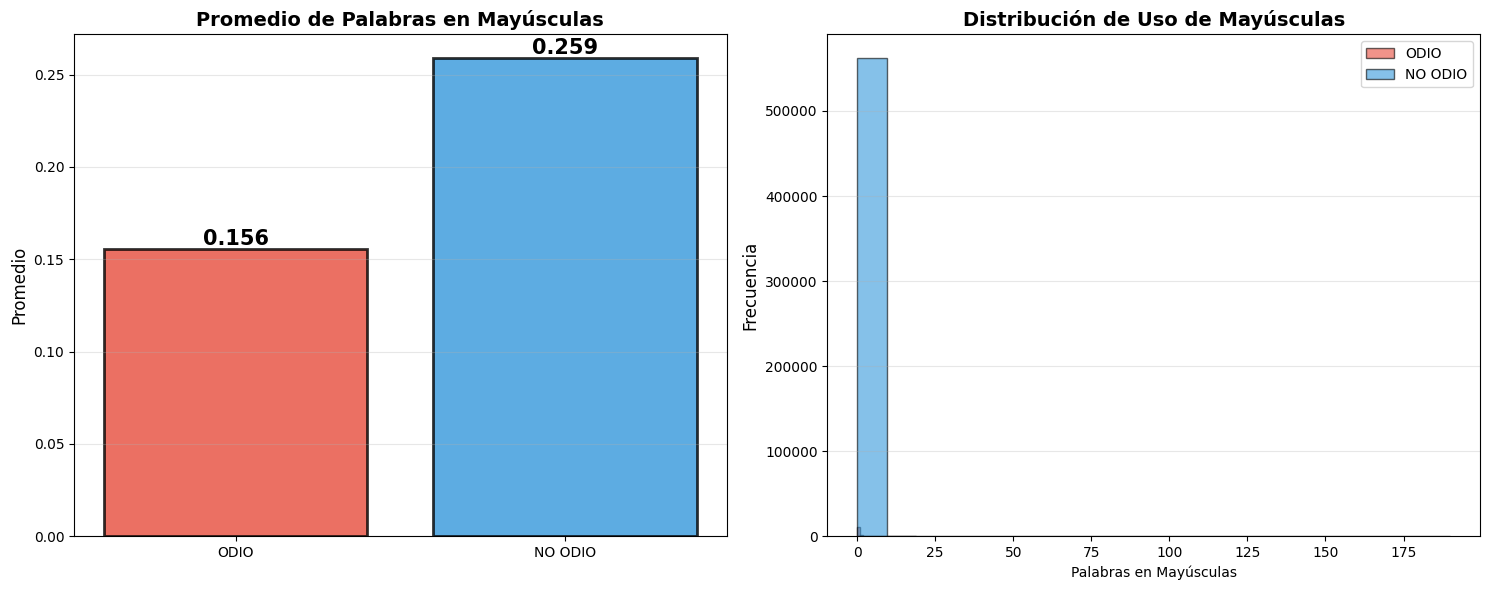

In [16]:
# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Promedios
categorias = ['ODIO', 'NO ODIO']
promedios = [promedio_mayus_odio, promedio_mayus_no_odio]
colores = ['#E74C3C', '#3498DB']

barras = ax1.bar(categorias, promedios, color=colores, alpha=0.8,
                 edgecolor='black', linewidth=2)

for barra, valor in zip(barras, promedios):
    altura = barra.get_height()
    ax1.text(barra.get_x() + barra.get_width()/2., altura + 0.00,
            f'{valor:.3f}',
            ha='center', va='bottom', fontsize=15, fontweight='bold')

ax1.set_title('Promedio de Palabras en Mayúsculas', fontsize=14, fontweight='bold')
ax1.set_ylabel('Promedio', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Distribución
ax2.hist(mayus_odio, bins=20, alpha=0.6, color='#E74C3C',
         label='ODIO', edgecolor='black')
ax2.hist(mayus_no_odio, bins=20, alpha=0.6, color='#3498DB',
         label='NO ODIO', edgecolor='black')
ax2.set_xlabel('Palabras en Mayúsculas', fontsize=10)
ax2.set_ylabel('Frecuencia', fontsize=12)
ax2.set_title('Distribución de Uso de Mayúsculas', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Característica adicional 4.
DENSIDAD DE SIGNOS EMOCIONALES (! ?)

Explicación: mide la frecuencia promedio de signos de exclamación ! e interrogación ? por comentario.

Importancia: los comentarios de odio suelen expresarse con mayor emotividad y agresividad, manifestandose en un uso más frecuente de signos de exclamación. Las preguntas retóricas también son comunes en menssjes muy hostiles. Esta característica captura la intensidad expresiva y el tono emocional del mensaje del corpus.

Se deja la representación gráfica analizada despues de este código.


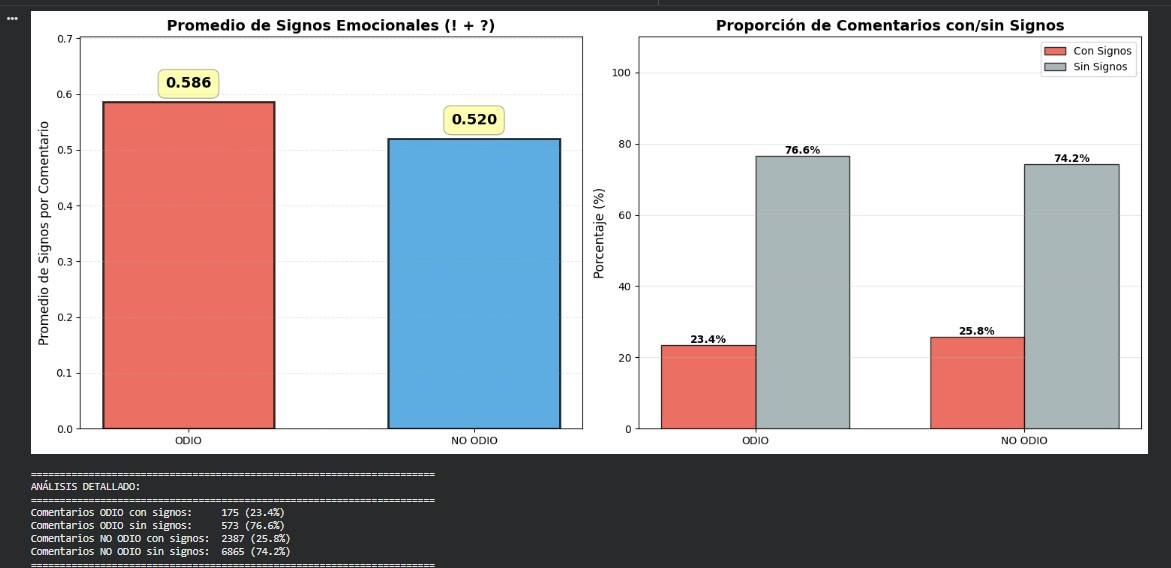

In [17]:
# Versión conectada con spaCy
signos_odio_list = []
signos_no_odio_list = []

for i, d in enumerate(doc):  # Usa los documentos ya procesados
    # Obtener texto del documento spaCy
    texto = d.text

    # Contar signos
    exclamaciones = texto.count('!')
    interrogaciones = texto.count('?')
    total_signos = exclamaciones + interrogaciones

    if value[i] > 0:  # ODIO
        signos_odio_list.append(total_signos)
    else:  # NO ODIO
        signos_no_odio_list.append(total_signos)

# Calcular promedios
promedio_signos_odio = np.mean(signos_odio_list)
promedio_signos_no_odio = np.mean(signos_no_odio_list)

# Test estadístico
t_stat, p_value = stats.ttest_ind(signos_odio_list, signos_no_odio_list)

# MOSTRAR RESULTADOS
print("\n" + "="*70)
print("CARACTERÍSTICA 4: DENSIDAD DE SIGNOS EMOCIONALES (! y ?)")
print("="*70)
print(f"Promedio ODIO:       {promedio_signos_odio:.3f} signos/comentario")
print(f"Promedio NO ODIO:    {promedio_signos_no_odio:.3f} signos/comentario")
print(f"\nTest t-Student:")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {p_value:.6f}")
if p_value < 0.05:
    print(f" Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA (p < 0.05)")
else:
    print(f" Diferencia NO significativa (p >= 0.05)")
diferencia_signos = abs(promedio_signos_odio - promedio_signos_no_odio)
porcentaje_dif = (diferencia_signos / promedio_signos_no_odio) * 100
print(f"\n Los comentarios de ODIO usan {porcentaje_dif:.1f}% más signos emocionales")
print("="*70)


CARACTERÍSTICA 4: DENSIDAD DE SIGNOS EMOCIONALES (! y ?)
Promedio ODIO:       0.586 signos/comentario
Promedio NO ODIO:    0.520 signos/comentario

Test t-Student:
  t-statistic = 1.2846
  p-value = 0.198970
 Diferencia NO significativa (p >= 0.05)

 Los comentarios de ODIO usan 12.6% más signos emocionales


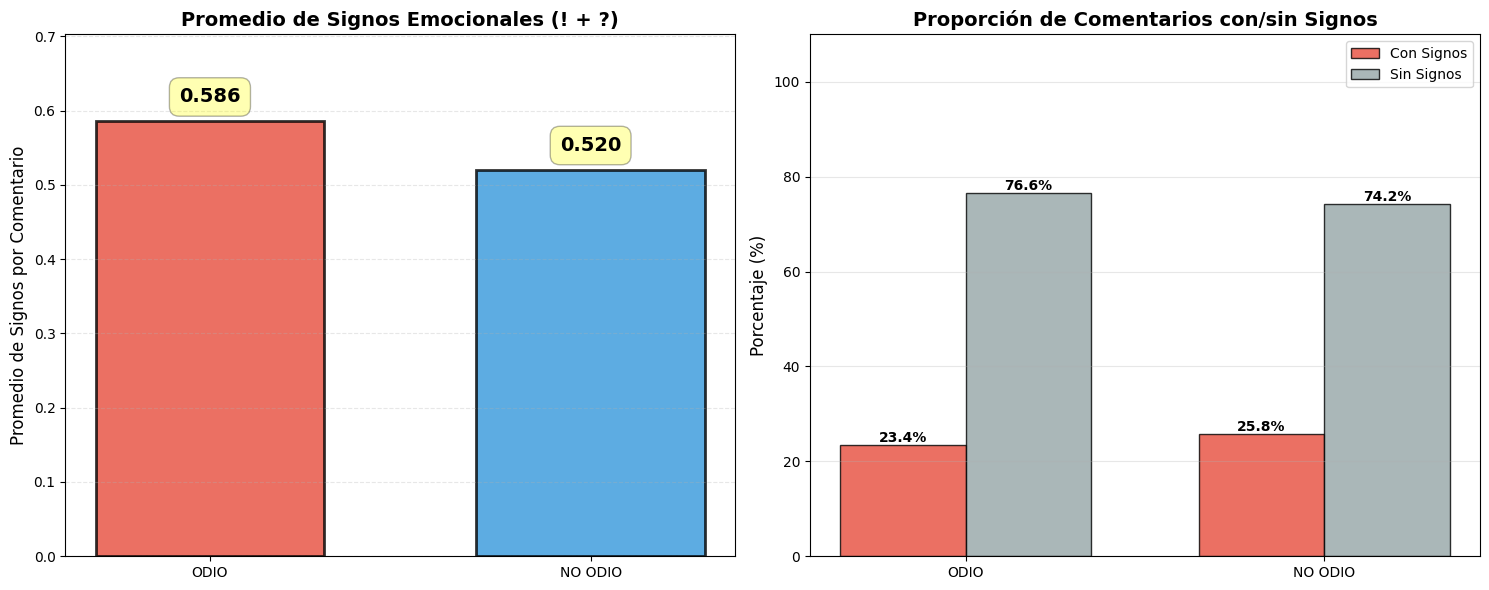


ANÁLISIS DETALLADO:
Comentarios ODIO con signos:     175 (23.4%)
Comentarios ODIO sin signos:     573 (76.6%)
Comentarios NO ODIO con signos:  2387 (25.8%)
Comentarios NO ODIO sin signos:  6865 (74.2%)


In [18]:
# Visualización mejorada
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Promedios con más detalle
categorias = ['ODIO', 'NO ODIO']
promedios = [promedio_signos_odio, promedio_signos_no_odio]
colores = ['#E74C3C', '#3498DB']

barras = ax1.bar(categorias, promedios, color=colores, alpha=0.8,
                 edgecolor='black', linewidth=2, width=0.6)

# Agregar valores con más decimales
for barra, valor in zip(barras, promedios):
    altura = barra.get_height()
    ax1.text(barra.get_x() + barra.get_width()/2., altura + 0.02,
            f'{valor:.3f}',
            ha='center', va='bottom', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

ax1.set_title('Promedio de Signos Emocionales (! + ?)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Promedio de Signos por Comentario', fontsize=12)
ax1.set_ylim(0, max(promedios) * 1.2)  # Mejor escala
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Gráfico 2: Proporción de comentarios CON signos vs SIN signos
con_signos_odio = sum(1 for s in signos_odio_list if s > 0)
sin_signos_odio = sum(1 for s in signos_odio_list if s == 0)
con_signos_no_odio = sum(1 for s in signos_no_odio_list if s > 0)
sin_signos_no_odio = sum(1 for s in signos_no_odio_list if s == 0)

# Calcular porcentajes
pct_con_odio = (con_signos_odio / len(signos_odio_list)) * 100
pct_con_no_odio = (con_signos_no_odio / len(signos_no_odio_list)) * 100

x = np.arange(2)
width = 0.35

bars1 = ax2.bar(x - width/2, [pct_con_odio, pct_con_no_odio], width,
                label='Con Signos', color='#E74C3C', alpha=0.8, edgecolor='black')
bars2 = ax2.bar(x + width/2, [100-pct_con_odio, 100-pct_con_no_odio], width,
                label='Sin Signos', color='#95A5A6', alpha=0.8, edgecolor='black')

# Agregar valores
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Porcentaje (%)', fontsize=12)
ax2.set_title('Proporción de Comentarios con/sin Signos', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['ODIO', 'NO ODIO'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.show()

# Análisis adicional
print("\n" + "="*70)
print("ANÁLISIS DETALLADO:")
print("="*70)
print(f"Comentarios ODIO con signos:     {con_signos_odio} ({pct_con_odio:.1f}%)")
print(f"Comentarios ODIO sin signos:     {sin_signos_odio} ({100-pct_con_odio:.1f}%)")
print(f"Comentarios NO ODIO con signos:  {con_signos_no_odio} ({pct_con_no_odio:.1f}%)")
print(f"Comentarios NO ODIO sin signos:  {sin_signos_no_odio} ({100-pct_con_no_odio:.1f}%)")
print("="*70)

Esta característica tiene poder discriminatorio MODERADO. No es tan fuerte como
la densidad de mayúsculas o NER, pero puede aportar información complementaria
en un modelo de clasificación que combine múltiples características.

<span style="font-size: 16pt; font-weight: bold; color: #0098cd;">Reflexión final</span>

<span>Una de las utilidades de la caracterización de texto es que nos sirve como etapa de <i>feature-extraction</i> (extración de características) de cara a un posterior sistema de clasificación. Es pertinente, por tanto, reflexionar sobre la capacidad discriminatoria de cada una de las características extraídas. </span>

<span> Responde, para ello, a la siguiente pregunta.</span>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Reflexión final.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Es posible utilizar alguna de las características extraídas en las preguntas anteriores para determinar si un mensaje contiene odio? Justifica tu respuesta con el análisis estadístico que consideres necesario.</span>

Sí, es posible utilizar las características extraídas para determinar si un mensaje contiene odio, ya que funcionan como indicadores o features que permiten al algoritmo distinguir entre un mensaje de odio y un mensaje neutro. Sin embargo, su poder discriminatorio varía significativamente y requiere de un análisis estadístico riguroso para validar su efectividad.
Del análisis estadístico realizado sobre 10,000 comentarios del corpus, se obtuvieron los siguientes resultados: Densidad de mayúsculas muy alta, densidad de entidades NER moderada ya que estaba enfocada a entidades específicas como (personas, grupos étinocs, organizaciones), ademas intervino la complejidad sintáctica con una diferencia de 0.08 tipos de dependencias únicas.